In [21]:
using Plots

In [22]:
# Simplified Marker And Cell method
# incompressible Navier-Stokes equation: dim = 2
# square cavity flow

mutable struct SMAC
    # grid parameters
    X_grid::Int
    Y_grid::Int
    size_X::Float64
    size_Y::Float64
    dx::Float64
    dy::Float64

    # time parameters
    t::Float64
    dt::Float64
    step_counter::Int
    dv_max::Float64

    # physical parameter
    viscosity_coef::Float64

    # hyper parameters
    cell_reynolds::Float64
    sor_acceleration_rate::Float64
    sor_convergence_criterion::Float64
    max_iter::Int
    cfl::Float64

    # value of cells
    velocity_x
    velocity_y
    velocity_x_new
    velocity_y_new
    pressure
    pressure_correction

    flux_right
    flux_upper

    # coefficients of discrete equation
    _ae
    _aw
    _an
    _as
    _ap
    _b

    # boundary condition
    velocity_of_upper_boundary::Float64

    function SMAC(X_grid, Y_grid, cell_reynolds; size_X=1.0, size_Y=1.0, velocity_of_upper_boundary=1.0, sor_acceleration_rate=1.8, sor_convergence_criterion=0.000001, max_iter=5000, cfl=0.5)
        dx = size_X / X_grid
        dy = size_Y / Y_grid
        t = 0.0
        viscosity_coef = 1.0 / cell_reynolds
        dt = cfl / (velocity_of_upper_boundary / dx + 2.0 * viscosity_coef * (1.0 / dx ^ 2 + 1.0 / dy ^ 2))
        step_counter = 0
        dv_max = 0.0

        velocity_x = zeros(X_grid+2, Y_grid+2)
        velocity_y = zeros(X_grid+2, Y_grid+2)
        velocity_x_new = zeros(X_grid+2, Y_grid+2)
        velocity_y_new = zeros(X_grid+2, Y_grid+2)
        pressure = zeros(X_grid+2, Y_grid+2)
        pressure_correction = zeros(X_grid+2, Y_grid+2)
        flux_right = zeros(X_grid+2, Y_grid+2)
        flux_upper = zeros(X_grid+2, Y_grid+2)

        _ae = zeros(X_grid+2, Y_grid+2)
        _aw = zeros(X_grid+2, Y_grid+2)
        _an = zeros(X_grid+2, Y_grid+2)
        _as = zeros(X_grid+2, Y_grid+2)
        _ap = zeros(X_grid+2, Y_grid+2)
        _b = zeros(X_grid+2, Y_grid+2)
        inv_dx = 1.0 / dx ^ 2
        inv_dy = 1.0 / dy ^ 2
        for i = 2 : X_grid + 1, j = 2 : Y_grid + 1
            _ae[i, j] = inv_dx
            _aw[i, j] = inv_dx
            _an[i, j] = inv_dy
            _as[i, j] = inv_dy
            _ap[i, j] = 2.0 * (inv_dx + inv_dy)

            if j == 2
                _ap[i, j] -= _as[i, j]
                _as[i, j] = 0.0
            end
            if j == Y_grid + 1
                _ap[i, j] -= _an[i, j]
                _an[i, j] = 0.0
            end
            if i == 2
                _ap[i, j] -= _aw[i, j]
                _aw[i, j] = 0.0
            end
            if i == X_grid + 1
                _ap[i, j] -= _ae[i, j]
                _ae[i, j] = 0.0
            end
        end

        new(X_grid, Y_grid, size_X, size_Y, dx, dy, t, dt, step_counter, dv_max, viscosity_coef,
            cell_reynolds, sor_acceleration_rate, sor_convergence_criterion, max_iter, cfl,
            velocity_x, velocity_y, velocity_x_new, velocity_y_new, pressure, pressure_correction, flux_right, flux_upper,
            _ae, _aw, _an, _as, _ap, _b, velocity_of_upper_boundary)
    end
end

function show_settings(smac)
    println("<settings>")
    println("X_grid = $(smac.X_grid), Y_grid = $(smac.Y_grid)\n(X_size, Y_size) = ($(smac.size_X), $(smac.size_Y))\ndx = $(smac.dx), dy = $(smac.dy)")
    println("viscosity_coef = $(smac.viscosity_coef), reynolds number = $(smac.cell_reynolds)\nsor_acceleration_rate = $(smac.sor_acceleration_rate), sor_convergence_criterion = $(smac.sor_convergence_criterion)")
    println("CFL number = $(smac.cfl), dt = $(smac.dt)")
    println("velocity_of_upper_boundary = $(smac.velocity_of_upper_boundary)\n")
end

function solve!(smac; method="center")
    show_settings(smac)
    while smac.step_counter < smac.max_iter
        smac.step_counter += 1
        smac.t += smac.dt
        boundary_condition!(smac)
        velocity_x_update!(smac, method)
        velocity_y_update!(smac, method)
        correction!(smac)
    end
end

function boundary_condition!(smac)
    for i = 2 : smac.X_grid + 1
        smac.velocity_x[i, 1] = -smac.velocity_x[i, 2]
        smac.velocity_x[i, smac.X_grid + 2] = 2.0 * smac.velocity_of_upper_boundary - smac.velocity_x[i, smac.X_grid + 1]
    end
    for j = 2 : smac.Y_grid + 1
        smac.velocity_y[1, j] = -smac.velocity_y[2, j]
        smac.velocity_y[smac.Y_grid + 2, j] = -smac.velocity_y[smac.Y_grid + 1, j]
    end
end

function velocity_x_update!(smac, method)
    for i = 1 : smac.X_grid, j = 1 : smac.Y_grid + 1
        v_x_boundary = 0.5 * (smac.velocity_x[i, j] + smac.velocity_x[i+1, j])
        v_y_boundary = 0.5 * (smac.velocity_y[i, j] + smac.velocity_y[i+1, j])

        if method == "center"
            smac.flux_right[i, j] = 0.5 * v_x_boundary * (smac.velocity_x[i+1, j] + smac.velocity_x[i, j]) - smac.viscosity_coef / smac.dx * (smac.velocity_x[i+1, j] - smac.velocity_x[i, j])
            smac.flux_upper[i, j] = 0.5 * v_y_boundary * (smac.velocity_x[i, j+1] + smac.velocity_x[i, j]) - smac.viscosity_coef / smac.dy * (smac.velocity_x[i, j+1] - smac.velocity_x[i, j])
        elseif method == "upwind"
            smac.flux_right[i, j] = 0.5 * v_x_boundary * (smac.velocity_x[i+1, j] + smac.velocity_x[i, j]) - (smac.viscosity_coef / smac.dx + 0.5 * abs(v_x_boundary)) * (smac.velocity_x[i+1, j] - smac.velocity_x[i, j])
            smac.flux_upper[i, j] = 0.5 * v_y_boundary * (smac.velocity_x[i, j+1] + smac.velocity_x[i, j]) - (smac.viscosity_coef / smac.dy + 0.5 * abs(v_y_boundary)) * (smac.velocity_x[i, j+1] - smac.velocity_x[i, j])
        else
            error("invalid method type: in velocity_x_update!")
        end
    end

    for i = 2 : smac.X_grid, j = 2 : smac.Y_grid + 1
        ∂t_velocity_x = (smac.flux_right[i-1, j] - smac.flux_right[i, j]) / smac.dx + (smac.flux_upper[i, j-1] - smac.flux_upper[i, j]) / smac.dy + (smac.pressure[i, j] - smac.pressure[i+1, j]) / smac.dx
        smac.velocity_x_new[i, j] = smac.velocity_x[i, j] + ∂t_velocity_x * smac.dt
    end
end

function velocity_y_update!(smac, method)
    for i = 1 : smac.X_grid + 1, j = 1 : smac.Y_grid
        v_x_boundary = 0.5 * (smac.velocity_x[i, j] + smac.velocity_x[i, j+1])
        v_y_boundary = 0.5 * (smac.velocity_y[i, j] + smac.velocity_y[i, j+1])

        if method == "center"
            smac.flux_right[i, j] = 0.5 * v_x_boundary * (smac.velocity_y[i+1, j] + smac.velocity_y[i, j]) - smac.viscosity_coef / smac.dx * (smac.velocity_y[i+1, j] - smac.velocity_y[i, j])
            smac.flux_upper[i, j] = 0.5 * v_y_boundary * (smac.velocity_y[i, j+1] + smac.velocity_y[i, j]) - smac.viscosity_coef / smac.dy * (smac.velocity_y[i, j+1] - smac.velocity_y[i, j])
        elseif method == "upwind"
            smac.flux_right[i, j] = 0.5 * v_x_boundary * (smac.velocity_y[i+1, j] + smac.velocity_y[i, j]) - (smac.viscosity_coef / smac.dx + 0.5 * abs(v_x_boundary)) * (smac.velocity_y[i+1, j] - smac.velocity_y[i, j])
            smac.flux_upper[i, j] = 0.5 * v_y_boundary * (smac.velocity_y[i, j+1] + smac.velocity_y[i, j]) - (smac.viscosity_coef / smac.dy + 0.5 * abs(v_y_boundary)) * (smac.velocity_y[i, j+1] - smac.velocity_y[i, j])
        else
            error("invalid method type: in velocity_y_update!")
        end
    end

    for i = 2 : smac.X_grid + 1, j = 2 : smac.Y_grid
        ∂t_velocity_y = (smac.flux_right[i-1, j] - smac.flux_right[i, j]) / smac.dx + (smac.flux_upper[i, j-1] - smac.flux_upper[i, j]) / smac.dy + (smac.pressure[i, j] - smac.pressure[i, j+1]) / smac.dy
        smac.velocity_y_new[i, j] = smac.velocity_y[i, j] + ∂t_velocity_y * smac.dt
    end
end

function correction!(smac)
    for i = 2 : smac.X_grid + 1, j = 2 : smac.Y_grid + 1
        smac._b[i, j] = - ((smac.velocity_x_new[i, j] - smac.velocity_x_new[i-1, j]) / smac.dx + (smac.velocity_y_new[i, j] - smac.velocity_y_new[i, j-1]) / smac.dy) / smac.dt
        smac.pressure_correction[i, j] = 0.0
    end
    sor_pressure_correction!(smac)

    dv_max = 0.0
    for i = 2 : smac.X_grid + 1, j = 2 : smac.Y_grid + 1
        v_old = smac.velocity_y[i, j]
        if i <= smac.X_grid
            smac.velocity_x[i, j] = smac.velocity_x_new[i, j] + smac.dt / smac.dx * (smac.pressure_correction[i, j] - smac.pressure_correction[i+1, j])
        end
        if j <= smac.Y_grid
            smac.velocity_y[i, j] = smac.velocity_y_new[i, j] + smac.dt / smac.dy * (smac.pressure_correction[i, j] - smac.pressure_correction[i, j+1])
        end
        smac.pressure[i, j] += smac.pressure_correction[i, j]
        dv_max = max(dv_max, abs(smac.velocity_y[i, j] - v_old))
    end
    smac.dv_max = dv_max
end

function sor_pressure_correction!(smac)
    iter = 0
    err = Inf64
    while err > smac.sor_convergence_criterion
        iter += 1
        err = 0.0
        for i = 2 : smac.X_grid + 1, j = 2 : smac.Y_grid + 1
            pressure_correction_new = (smac._aw[i, j] * smac.pressure_correction[i-1, j] + smac._ae[i, j] * smac.pressure_correction[i+1, j] + smac._as[i, j] * smac.pressure_correction[i, j-1] + smac._an[i, j] * smac.pressure_correction[i, j+1] + smac._b[i, j]) / smac._ap[i, j]
            err = max(err, abs(pressure_correction_new - smac.pressure_correction[i, j]))
            smac.pressure_correction[i, j] += smac.sor_acceleration_rate * (pressure_correction_new - smac.pressure_correction[i, j])
        end

        if iter % 10000 == 0
            println("iter = $(iter), error = $(err)")
        elseif iter > 1000000
            println("convergence is too late: at SOR method: in step = $(smac.step_counter)")
            break
        end
    end
end

function plot_velocity(smac; decimation=1, scale=2.0)
    x = []
    y = []
    velocity_x = []
    velocity_y = []
    _scale = smac.dx * decimation * scale / smac.velocity_of_upper_boundary
    for i = 2 : decimation : smac.X_grid + 1
        for j = 2 : decimation : smac.Y_grid + 1
            v_x_center = 0.5 * (smac.velocity_x[i, j] + smac.velocity_x[i-1, j])
            v_y_center = 0.5 * (smac.velocity_y[i, j] + smac.velocity_y[i, j-1])
            push!(x, (i - 1.5) * smac.dx)
            push!(y, (j - 1.5) * smac.dy)
            push!(velocity_x, v_x_center * _scale)
            push!(velocity_y, v_y_center * _scale)
        end
    end

    quiver(x, y, quiver=(velocity_x, velocity_y))
end

function plot_pressure(smac)
    x = [(i - 1.5) * smac.dx for i = 2 : smac.X_grid + 1]
    y = [(j - 1.5) * smac.dx for j = 2 : smac.Y_grid + 1]
    p = smac.pressure[2 : smac.X_grid + 1, 2 : smac.Y_grid + 1]

    contour(x, y, transpose(p))
end

function plot_streamline(smac)
    flow = zeros(smac.X_grid + 1, smac.Y_grid + 1)
    for i = 1 : smac.X_grid + 1
        for j = 2 : smac.Y_grid
            flow[i, j] = flow[i, j-1] + smac.velocity_x[i, j] * smac.dx
        end
    end

    x = [(i - 1) * smac.dx for i = 1 : smac.X_grid + 1]
    y = [(j - 1) * smac.dy for j = 1 : smac.Y_grid + 1]
    contour(x, y, transpose(flow))
end

function plot_v_x_on_halfline(smac)
    half = div(smac.Y_grid, 2) + 1
    y = [(j - 2) * smac.dy for j = 2 : smac.Y_grid + 1]
    u = [smac.velocity_x[half, j] for j = 2 : smac.Y_grid + 1]
    plot(y, u, permute=(:y, :x))
end

plot_v_x_on_halfline (generic function with 1 method)

In [23]:
X_grid = 40
Y_grid = 40
Reynolds = 100.0
decimation = div(X_grid, 10)

4

In [24]:
smac = SMAC(X_grid, Y_grid, Reynolds)
solve!(smac)

<settings>
X_grid = 40, Y_grid = 40
(X_size, Y_size) = (1.0, 1.0)
dx = 0.025, dy = 0.025
viscosity_coef = 0.01, reynolds number = 100.0
sor_acceleration_rate = 1.8, sor_convergence_criterion = 1.0e-6
CFL number = 0.5, dt = 0.004807692307692308
velocity_of_upper_boundary = 1.0



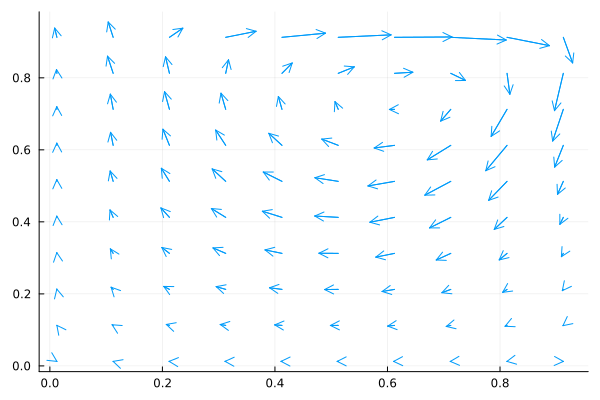

In [25]:
plot_velocity(smac, decimation=decimation, scale=2.0)

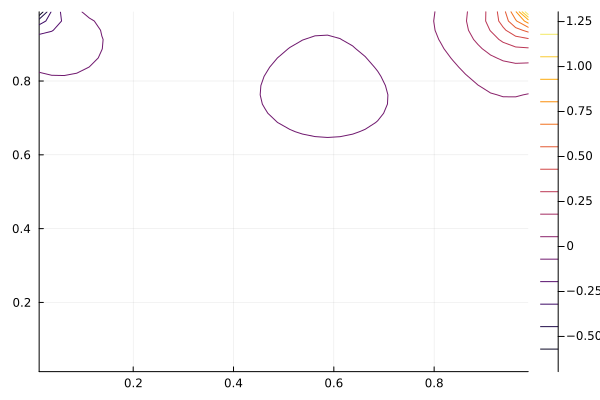

In [26]:
plot_pressure(smac)

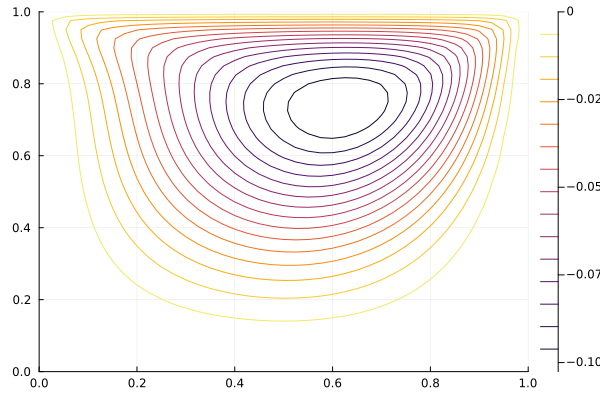

In [27]:
plot_streamline(smac)

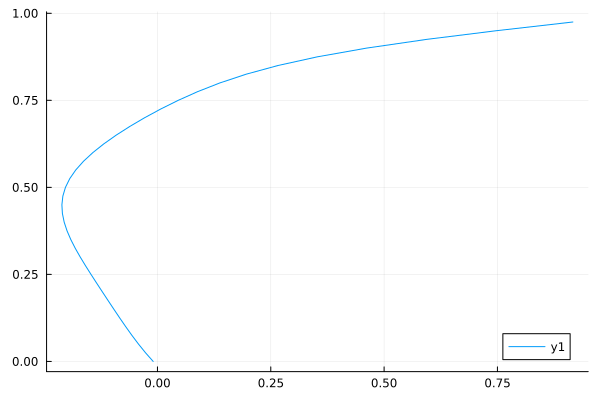

In [28]:
plot_v_x_on_halfline(smac)

In [29]:
smac2 = SMAC(80, 80, 400)
solve!(smac2)

<settings>
X_grid = 80, Y_grid = 80
(X_size, Y_size) = (1.0, 1.0)
dx = 0.0125, dy = 0.0125
viscosity_coef = 0.0025, reynolds number = 400.0
sor_acceleration_rate = 1.8, sor_convergence_criterion = 1.0e-6
CFL number = 0.5, dt = 0.003472222222222222
velocity_of_upper_boundary = 1.0



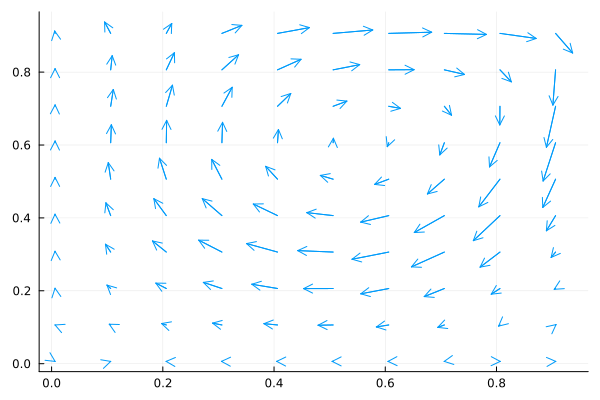

In [30]:
plot_velocity(smac2, decimation=8, scale=2.0)

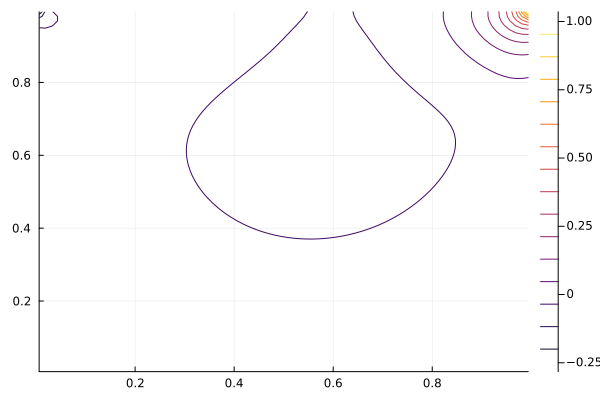

In [31]:
plot_pressure(smac2)

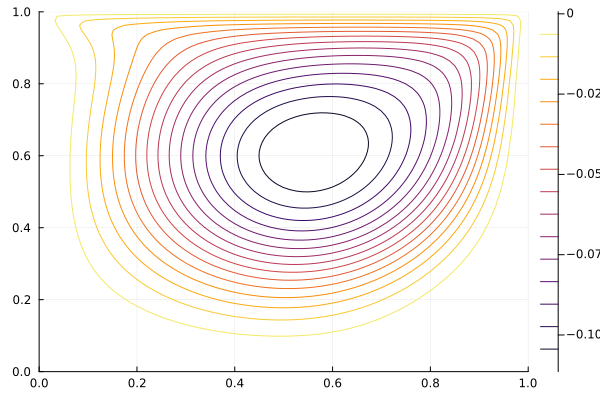

In [32]:
plot_streamline(smac2)

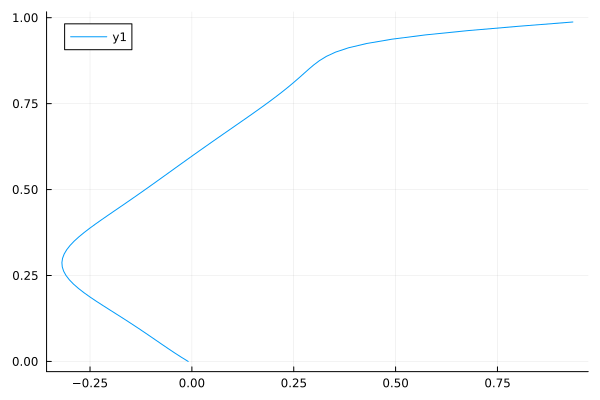

In [33]:
plot_v_x_on_halfline(smac2)